In [1]:
import spatialdata as sd
from spatialdata import models
import spatialdata_plot
import sopa
import matplotlib.pyplot as plt

/users/sansom/tme871/devel/venvs/python-3.10.8-GCCcore-12.2.0-skylake-cgat-spatial/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


In [21]:
# some graphical parameters
import seaborn as sns
from spatialdata import bounding_box_query
def crop0(x):
    return bounding_box_query(
        x,
        min_coordinate=[4000, 6000],
        max_coordinate=[6000, 8000],
        axes=("x", "y"),
        target_coordinate_system="global",
    )

## Importing `SpatialData` 

In [11]:
# Path to .zarr file
path2zarr = './zarr.dir/NL5H1a/D07_dist3.zarr/'
sdata = sd.read_zarr(path2zarr)
sdata

/users/sansom/tme871/devel/venvs/python-3.10.8-GCCcore-12.2.0-skylake-cgat-spatial/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)


SpatialData object, with associated Zarr store: /gpfs3/well/sansom/users/tme871/work/cosmx_mouse/spatialhub/zarr.dir/NL5H1a/D07_dist3.zarr
├── Images
│     └── 'image': DataArray[cyx] (5, 16965, 16965)
├── Points
│     ├── 'tx_ctrl': DataFrame with shape: (<Delayed>, 7) (2D points)
│     ├── 'tx_main': DataFrame with shape: (<Delayed>, 7) (2D points)
│     └── 'tx_other': DataFrame with shape: (<Delayed>, 7) (2D points)
└── Shapes
      └── 'atomx': GeoDataFrame shape: (17759, 2) (2D shapes)
with coordinate systems:
    ▸ 'global', with elements:
        image (Images), tx_ctrl (Points), tx_main (Points), tx_other (Points), atomx (Shapes)

In [12]:
# Set atomx mask index to desired cell keys, to avoid indexing issues later
sdata['atomx'].index = sdata['atomx']['atomx_index']
sdata['atomx'].index.name = None
sdata['atomx'].index

Index(['FOV41_C413', 'FOV33_C1103', 'FOV34_C350', 'FOV35_C1389', 'FOV37_C1783',
       'FOV38_C458', 'FOV36_C1546', 'FOV33_C1013', 'FOV35_C888', 'FOV36_C1360',
       ...
       'FOV35_C1249', 'FOV36_C314', 'FOV37_C728', 'FOV33_C1126', 'FOV31_C165',
       'FOV32_C889', 'FOV40_C688', 'FOV36_C1803', 'FOV36_C1134',
       'FOV31_C1758'],
      dtype='object', length=17759)

In [17]:
sdata0 = sdata
sdata0

SpatialData object, with associated Zarr store: /gpfs3/well/sansom/users/tme871/work/cosmx_mouse/spatialhub/zarr.dir/NL5H1a/D07_dist3.zarr
├── Images
│     └── 'image': DataArray[cyx] (5, 16965, 16965)
├── Points
│     ├── 'tx_ctrl': DataFrame with shape: (<Delayed>, 7) (2D points)
│     ├── 'tx_main': DataFrame with shape: (<Delayed>, 7) (2D points)
│     └── 'tx_other': DataFrame with shape: (<Delayed>, 7) (2D points)
└── Shapes
      └── 'atomx': GeoDataFrame shape: (17759, 2) (2D shapes)
with coordinate systems:
    ▸ 'global', with elements:
        image (Images), tx_ctrl (Points), tx_main (Points), tx_other (Points), atomx (Shapes)

#### Option 1: Aggregate tx to AnnData using SOPA

In [4]:
#sopa.aggregate(sdata, shapes_key = 'atomx', points_key = 'tx_main', aggregate_channels = False) 
# This raises an error - for some reason the `points_key` argument is not recognized, despite being described in the SOPA API...

In [16]:
# Subsetting sdata object to one single transcripts table, and renaming it as expected by default in SOPA
sdata = sdata0.subset(['image', 'atomx', 'tx_main'])
sdata['transcripts'] = sdata['tx_main']
del sdata['tx_main']
sdata

SpatialData object
├── Images
│     └── 'image': DataArray[cyx] (5, 16965, 16965)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 7) (2D points)
└── Shapes
      └── 'atomx': GeoDataFrame shape: (17759, 2) (2D shapes)
with coordinate systems:
    ▸ 'global', with elements:
        image (Images), transcripts (Points), atomx (Shapes)

In [18]:
sopa.aggregate(sdata, shapes_key = 'atomx', aggregate_channels = False)
sdata

[INFO] (sopa.aggregation.transcripts) Aggregating transcripts over 17759 cells
/users/sansom/tme871/devel/venvs/python-3.10.8-GCCcore-12.2.0-skylake-cgat-spatial/lib/python3.10/site-packages/anndata/_core/storage.py:48: FutureWarning: AnnData previously had undefined behavior around matrices of type <class 'scipy.sparse._coo.coo_matrix'>.In 0.12, passing in this type will throw an error. Please convert to a supported type.Continue using for this minor version at your own risk.
  warnings.warn(msg, FutureWarning)


[########################################] | 100% Completed | 5.06 ss


/users/sansom/tme871/devel/venvs/python-3.10.8-GCCcore-12.2.0-skylake-cgat-spatial/lib/python3.10/site-packages/spatialdata/_core/_elements.py:105: UserWarning: Key `atomx` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


SpatialData object
├── Images
│     └── 'image': DataArray[cyx] (5, 16965, 16965)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 7) (2D points)
├── Shapes
│     └── 'atomx': GeoDataFrame shape: (17759, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (17759, 974)
with coordinate systems:
    ▸ 'global', with elements:
        image (Images), transcripts (Points), atomx (Shapes)

In [19]:
adata = sdata['table']
adata

AnnData object with n_obs × n_vars = 17759 × 974
    obs: 'region', 'slide', 'cell_id', 'area'
    uns: 'sopa_attrs', 'spatialdata_attrs'
    obsm: 'spatial'

In [20]:
adata.uns['spatialdata_attrs']

{'region': 'atomx', 'region_key': 'region', 'instance_key': 'cell_id'}

/apps/eb/2020b/skylake/software/Python/3.10.8-GCCcore-12.2.0/lib/python3.10/functools.py:889: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)
/users/sansom/tme871/devel/venvs/python-3.10.8-GCCcore-12.2.0-skylake-cgat-spatial/lib/python3.10/site-packages/spatialdata/_core/_elements.py:105: UserWarning: Key `atomx` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/users/sansom/tme871/devel/venvs/python-3.10.8-GCCcore-12.2.0-skylake-cgat-spatial/lib/python3.10/site-packages/spatialdata/_core/_elements.py:125: UserWarning: Key `table` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


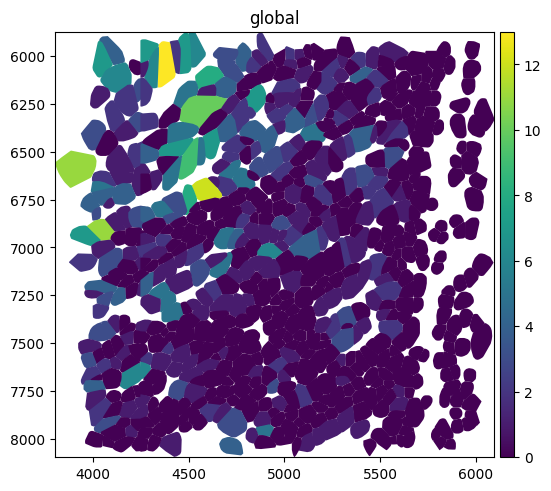

In [22]:
crop0(sdata).pl.render_shapes("atomx", color="Epcam").pl.show()
#plt.draw()
#plt.show()

#### Option 2: Aggregate tx to AnnData using SpatialData

In [23]:
sdata = sdata0

# This option has the advantage of enabling to retain all transcripts layers in the object
adata = sd.aggregate(values = sdata["tx_main"], by = sdata["atomx"], 
                     agg_func = "sum", target_coordinate_system = "global",
                     region_key = "segmentation_mask")["table"]

# Update spatialdata attributes to some more intuitive names than default
adata.obs['segmentation_mask'] = 'atomx'
adata.uns['spatialdata_attrs']['region'] = 'atomx'

# Append AnnData to SpatialData object
adata = models.TableModel.parse(adata)
sdata["anndata"] = adata
sdata

/users/sansom/tme871/devel/venvs/python-3.10.8-GCCcore-12.2.0-skylake-cgat-spatial/lib/python3.10/site-packages/spatialdata/_core/operations/aggregate.py:453: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aggregated = joined.groupby([INDEX, vk])[ONES_COLUMN].agg(agg_func).reset_index()
/users/sansom/tme871/devel/venvs/python-3.10.8-GCCcore-12.2.0-skylake-cgat-spatial/lib/python3.10/site-packages/anndata/_core/anndata.py:401: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/users/sansom/tme871/devel/venvs/python-3.10.8-GCCcore-12.2.0-skylake-cgat-spatial/lib/python3.10/site-packages/spatialdata/models/models.py:1053: UserWarning: Converting `region_key: segmentation_mask` to categorical dtype.
  return convert_region_column_to_categorical(adata)


SpatialData object, with associated Zarr store: /gpfs3/well/sansom/users/tme871/work/cosmx_mouse/spatialhub/zarr.dir/NL5H1a/D07_dist3.zarr
├── Images
│     └── 'image': DataArray[cyx] (5, 16965, 16965)
├── Points
│     ├── 'tx_ctrl': DataFrame with shape: (<Delayed>, 7) (2D points)
│     ├── 'tx_main': DataFrame with shape: (<Delayed>, 7) (2D points)
│     └── 'tx_other': DataFrame with shape: (<Delayed>, 7) (2D points)
├── Shapes
│     └── 'atomx': GeoDataFrame shape: (17759, 2) (2D shapes)
└── Tables
      └── 'anndata': AnnData (17759, 974)
with coordinate systems:
    ▸ 'global', with elements:
        image (Images), tx_ctrl (Points), tx_main (Points), tx_other (Points), atomx (Shapes)
with the following elements not in the Zarr store:
    ▸ anndata (Tables)

In [24]:
adata = sdata['anndata']
adata

AnnData object with n_obs × n_vars = 17759 × 974
    obs: 'instance_id', 'segmentation_mask'
    uns: 'spatialdata_attrs'

In [25]:
adata.uns['spatialdata_attrs']

{'region': 'atomx',
 'region_key': 'segmentation_mask',
 'instance_key': 'instance_id'}

/apps/eb/2020b/skylake/software/Python/3.10.8-GCCcore-12.2.0/lib/python3.10/functools.py:889: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)
/users/sansom/tme871/devel/venvs/python-3.10.8-GCCcore-12.2.0-skylake-cgat-spatial/lib/python3.10/site-packages/spatialdata/_core/_elements.py:105: UserWarning: Key `atomx` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/users/sansom/tme871/devel/venvs/python-3.10.8-GCCcore-12.2.0-skylake-cgat-spatial/lib/python3.10/site-packages/spatialdata/_core/_elements.py:125: UserWarning: Key `anndata` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


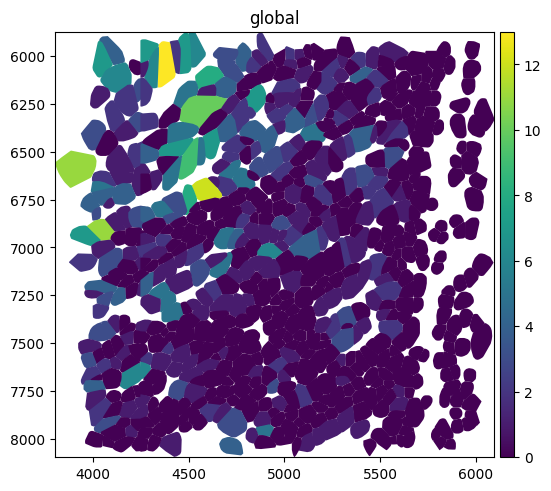

In [26]:
crop0(sdata).pl.render_shapes("atomx", color="Epcam").pl.show()
#plt.draw()
#plt.show()